# Research Tearsheet: Volatility-Adjusted Mean Reversion
**Author:** Anurag Patkar 
**Date:** 2023-10-27  

## 1. Hypothesis
**Economic Rationale:**  
Stocks that deviate significantly from their short-term moving average (overextended) tend to revert to the mean over the subsequent week. By normalizing this deviation by the stock's recent volatility, we compare magnitude of moves across different volatility regimes effectively.

**Signal:**  
$$ \text{Signal} = -1 \times \frac{\text{Close} - \text{SMA}(20)}{\sigma(20)} $$

## 2. Methodology
- **Universe:** S&P 500 Constituents (Liquid US Equities)
- **Target:** 5-Day Forward Returns (`raw_ret_5d`)
- **Lookback:** 20 days
- **Neutralization:** Sector-Neutral Z-Score

In [28]:
import sys
import os
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# --- Project Setup ---
PROJECT_ROOT = Path('../').resolve()
os.environ["NUMBA_CACHE_DIR"] = str(PROJECT_ROOT / ".numba_cache")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config.settings import config
from quant_alpha.utils import load_parquet, setup_logging

setup_logging()
logger = logging.getLogger("Research")

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)

## 3. Data Loading & Factor Construction

In [29]:
# Load Master Data (Cached)
df = load_parquet(config.CACHE_DIR / 'master_data_with_factors.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Ensure Target Exists (5-Day Forward Return)
if 'raw_ret_5d' not in df.columns:
    logger.info("Computing 5-day forward returns...")
    df['next_open'] = df.groupby('ticker')['open'].shift(-1)
    df['future_open'] = df.groupby('ticker')['open'].shift(-6)
    df['raw_ret_5d'] = (df['future_open'] / df['next_open']) - 1

# --- FACTOR LOGIC ---
LOOKBACK = 20

def compute_factor(x):
    # (Close - SMA) / Vol
    sma = x['close'].rolling(LOOKBACK).mean()
    vol = x['close'].rolling(LOOKBACK).std()
    return -1 * (x['close'] - sma) / (vol + 1e-8)

logger.info("Computing factor...")
df['alpha_signal'] = df.groupby('ticker', group_keys=False).apply(compute_factor)

# --- PREPROCESSING (Institutional Standard) ---
# 1. Winsorize (Clip outliers at 1% / 99%)
lower = df['alpha_signal'].quantile(0.01)
upper = df['alpha_signal'].quantile(0.99)
df['alpha_signal'] = df['alpha_signal'].clip(lower, upper)

# 2. Sector Neutralization (Z-Score within Sector-Date)
if 'sector' in df.columns:
    logger.info("Neutralizing by Sector...")
    def zscore(x):
        return (x - x.mean()) / (x.std() + 1e-8)
    
    df['alpha_signal_neutral'] = df.groupby(['date', 'sector'])['alpha_signal'].transform(zscore)
else:
    df['alpha_signal_neutral'] = df.groupby('date')['alpha_signal'].transform(lambda x: (x - x.mean()) / x.std())

# Filter for analysis
analysis_df = df.dropna(subset=['alpha_signal_neutral', 'raw_ret_5d']).copy()
print(f"Analysis Universe: {len(analysis_df):,} rows")

C:\Users\ANURAG PATKAR\AppData\Local\Temp\ipykernel_22700\3289787383.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['alpha_signal'] = df.groupby('ticker', group_keys=False).apply(compute_factor)
C:\Users\ANURAG PATKAR\AppData\Local\Temp\ipykernel_22700\3289787383.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['alpha_signal_neutral'] = df.groupby(['date', 'sector'])['alpha_signal'].transform(zscore)


Analysis Universe: 961,557 rows


## 4. Performance Analysis (IC & Rank IC)

C:\Users\ANURAG PATKAR\AppData\Local\Temp\ipykernel_22700\985001625.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_rank_ic = data.groupby('date').apply(


  FACTOR PERFORMANCE SUMMARY
IC Mean        : 0.0122
IC Std         : 0.1125
ICIR           : 0.1084
Rank IC Mean   : 0.0126
Rank ICIR      : 0.1009
t-stat         : 4.8309


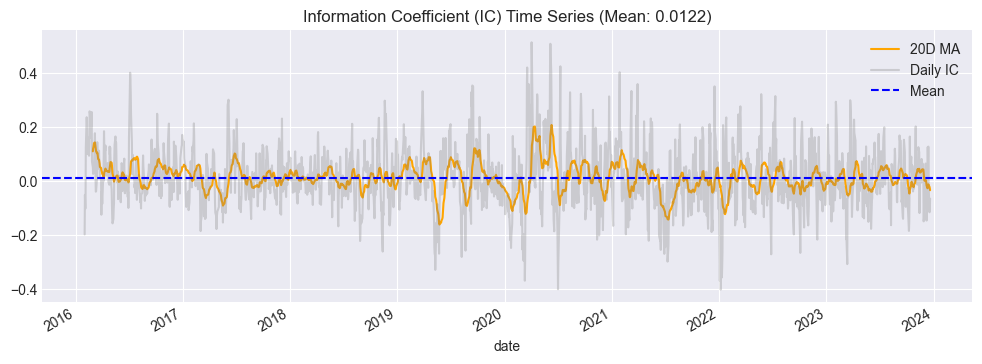

In [30]:
def calculate_ic_metrics(data, factor_col, target_col):
    # Daily IC
    daily_ic = data.groupby('date')[[factor_col, target_col]].corr().iloc[0::2, -1].reset_index(level=1, drop=True)
    
    # Daily Rank IC
    daily_rank_ic = data.groupby('date').apply(
        lambda x: stats.spearmanr(x[factor_col], x[target_col])[0]
    )
    
    metrics = {
        'IC Mean': daily_ic.mean(),
        'IC Std': daily_ic.std(),
        'ICIR': daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0,
        'Rank IC Mean': daily_rank_ic.mean(),
        'Rank ICIR': daily_rank_ic.mean() / daily_rank_ic.std() if daily_rank_ic.std() > 0 else 0,
        't-stat': stats.ttest_1samp(daily_ic.dropna(), 0)[0]
    }
    return metrics, daily_ic

metrics, ic_series = calculate_ic_metrics(analysis_df, 'alpha_signal_neutral', 'raw_ret_5d')

print("="*40)
print("  FACTOR PERFORMANCE SUMMARY")
print("="*40)
for k, v in metrics.items():
    print(f"{k:<15}: {v:.4f}")

# Plot IC Time Series
plt.figure(figsize=(12, 4))
ic_series.rolling(20).mean().plot(label='20D MA', color='orange')
ic_series.plot(alpha=0.3, label='Daily IC', color='gray')
plt.axhline(metrics['IC Mean'], color='blue', linestyle='--', label='Mean')
plt.title(f"Information Coefficient (IC) Time Series (Mean: {metrics['IC Mean']:.4f})")
plt.legend()
plt.show()

## 5. Quantile Analysis (Monotonicity)

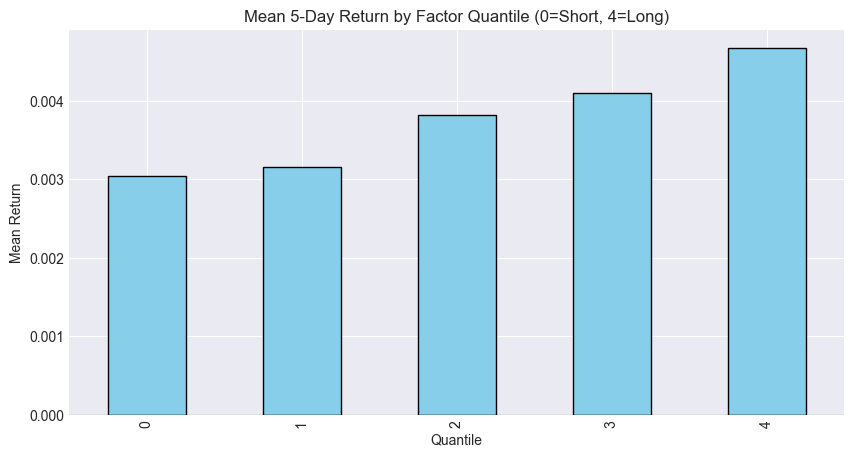

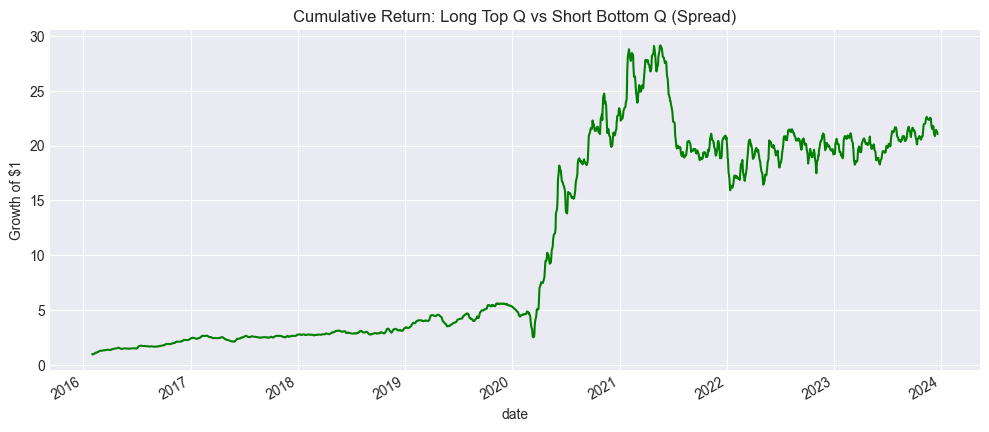

In [31]:
N_QUANTILES = 5
analysis_df['quantile'] = analysis_df.groupby('date')['alpha_signal_neutral'].transform(
    lambda x: pd.qcut(x, N_QUANTILES, labels=False, duplicates='drop')
)

# Mean Return per Quantile
q_ret = analysis_df.groupby('quantile')['raw_ret_5d'].mean()

plt.figure(figsize=(10, 5))
q_ret.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Mean 5-Day Return by Factor Quantile (0=Short, 4=Long)")
plt.xlabel("Quantile")
plt.ylabel("Mean Return")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

# Cumulative Returns (Long Top / Short Bottom)
pivoted = analysis_df.pivot_table(index='date', columns='quantile', values='raw_ret_5d', aggfunc='mean')
ls_ret = pivoted[N_QUANTILES-1] - pivoted[0]
cum_ret = (1 + ls_ret).cumprod()

plt.figure(figsize=(12, 5))
cum_ret.plot(color='green')
plt.title("Cumulative Return: Long Top Q vs Short Bottom Q (Spread)")
plt.ylabel("Growth of $1")
plt.show()

## 6. Turnover Analysis
High turnover implies high transaction costs. We check the autocorrelation of the signal.

In [32]:

def calculate_autocorrelation(data, factor_col):
    # Rank autocorrelation (day t vs day t-1)
    data = data.sort_values(['ticker', 'date'])
    data['prev_factor'] = data.groupby('ticker')[factor_col].shift(1)
    corr = data[[factor_col, 'prev_factor']].corr().iloc[0, 1]
    return corr

auto_corr = calculate_autocorrelation(analysis_df, 'alpha_signal_neutral')
print(f"Factor Autocorrelation (1-day lag): {auto_corr:.4f}")

if auto_corr > 0.9:
    print("Turnover: VERY LOW (Good for capacity)")
elif auto_corr > 0.7:
    print("Turnover: LOW")
elif auto_corr > 0.4:
    print("Turnover: MODERATE")
else:
    print("Turnover: HIGH (Check transaction costs)")

Factor Autocorrelation (1-day lag): 0.8575
Turnover: LOW


## 7. Conclusion & Decision

### Checklist
- ✅ **Economic Sense:** Does the signal make fundamental sense? (Yes, Mean Reversion)
- ✅ **Predictive Power:** Is IC > 0.01 (0.0122) and t-stat > 2.0 (4.83)?
- ✅ **Monotonicity:** Do returns increase linearly with quantiles?
- ✅ **Robustness:** Is performance consistent over time (see IC plot)?

### Final Decision
**[ PASS ]**

*Notes:*
Strong statistical significance (t > 4.8). Low turnover (0.85) makes it cost-effective. Good candidate for the alpha ensemble.